# Crypto Limit Order Book Analysis
## Part 1: Exploratory Data Analysis & Feature Engineering

**Author:** Rishabh
**Dataset:** High-Frequency Crypto LOB Data (Coinbase)
**Assets:** BTC, ETH, ADA | **Frequency:** 1-second snapshots

---

### Objective
Analyze limit order book dynamics to understand market microstructure and engineer features for short-term price movement prediction.

### Data Description
- 15 levels of bid/ask depth
- Features include: midpoint, spread, distance from midprice, market/limit/cancel order volumes
- Source: [Kaggle](https://www.kaggle.com/datasets/martinsn/high-frequency-crypto-limit-order-book-data)

In [10]:
# ===========
# IMPORTS
# ===========
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_style('whitegrid')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [14]:
# ===============
# IMPORTING DATA
# ===============
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/BTC_1sec.csv')
print(df.shape)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1030728, 156)
   Unnamed: 0                       system_time  midpoint  spread  buys  \
0           0  2021-04-07 11:32:42.122161+00:00  56036.00    0.01  0.00   
1           1  2021-04-07 11:32:43.122161+00:00  56036.00    0.01  0.00   
2           2  2021-04-07 11:32:44.122161+00:00  56036.00    0.01  0.00   
3           3  2021-04-07 11:32:45.122161+00:00  56036.00    0.01  0.00   
4           4  2021-04-07 11:32:46.122161+00:00  56036.00    0.01  0.00   

   sells  bids_distance_0  bids_distance_1  bids_distance_2  bids_distance_3  \
0   0.00            -0.00            -0.00            -0.00            -0.00   
1   0.00            -0.00            -0.00            -0.00            -0.00   
2   0.00            -0.00            -0.00            -0.00            -0.00   
3   0.00            -0.00            -0.00            -0.00            -0.00   
4   0

---
## Data Dictionary

### Core Price Metrics
| Column | Description |
|--------|-------------|
| `system_time` | Timestamp of LOB snapshot (1-second frequency) |
| `midpoint` | Mid-price: average of best bid and best ask |
| `spread` | Best ask − best bid (in dollars) |
| `buys` | Total notional value of buy market orders in this interval |
| `sells` | Total notional value of sell market orders in this interval |

### Distance Columns (30 total: 15 bid + 15 ask)
| Column Pattern | Description |
|----------------|-------------|
| `bids_distance_X` | Distance of bid level X from midpoint (as %). Level 0 = best bid |
| `asks_distance_X` | Distance of ask level X from midpoint (as %). Level 0 = best ask |

*Example: `bids_distance_0 = -0.0001` means best bid is 0.01% below midpoint*

### Notional Columns (120 total: 4 types × 15 levels × 2 sides)
| Column Pattern | Description |
|----------------|-------------|
| `bids_notional_X` / `asks_notional_X` | Total resting order value ($) at level X |
| `bids_limit_notional_X` / `asks_limit_notional_X` | New limit orders added at level X during this second |
| `bids_market_notional_X` / `asks_market_notional_X` | Market orders that consumed liquidity at level X |
| `bids_cancel_notional_X` / `asks_cancel_notional_X` | Orders cancelled at level X during this second |

### Microstructure Intuition
- **Limit orders** = Passive liquidity provision ("I'll buy at $X if price comes to me")
- **Market orders** = Aggressive liquidity consumption ("I'll buy NOW at best available price")
- **Cancellations** = Withdrawn liquidity (could signal informed trading or spoofing)
- **Order flow imbalance** = Excess buying vs selling pressure → predictive of price direction

In [15]:
# ============================================================
# BASIC DATA INSPECTION
# ============================================================

# Check shape and memory
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTime Range: {df['system_time'].min()} to {df['system_time'].max()}")



Dataset Shape: 1,030,728 rows × 156 columns

Time Range: 2021-04-07 11:32:42.122161+00:00 to 2021-04-19 09:54:22.386544+00:00


In [16]:
# ======================================
# DATA QUALITY & SUMMARY STATISTICS
# ======================================

# 1. Check for missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print(" No missing values found\n")
else:
    print(f"Missing values in {len(missing_cols)} columns:")
    print(missing_cols.head(10))

# 2. Convert timestamp to datetime
df['system_time'] = pd.to_datetime(df['system_time'])

# 3. Summary statistics for core columns
core_cols = ['midpoint', 'spread', 'buys', 'sells']
print("="*60)
print("CORE METRICS SUMMARY")
print("="*60)
print(df[core_cols].describe().round(2))

# 4. Check for anomalies
print("\n" + "="*60)
print("ANOMALY CHECKS")
print("="*60)
print(f"Negative spreads: {(df['spread'] < 0).sum()}")
print(f"Zero spreads: {(df['spread'] == 0).sum()}")
print(f"Midpoint range: ${df['midpoint'].min():,.2f} - ${df['midpoint'].max():,.2f}")
print(f"Max single-second buys: ${df['buys'].max():,.0f}")
print(f"Max single-second sells: ${df['sells'].max():,.0f}")

 No missing values found

CORE METRICS SUMMARY
        midpoint     spread       buys      sells
count 1030728.00 1030728.00 1030728.00 1030728.00
mean    59975.07       1.31    6060.06    5278.90
std      2490.05       4.71   32348.19   35807.57
min     51978.18       0.01       0.00       0.00
25%     58000.00       0.01       8.97       0.00
50%     60146.58       0.01     264.09       0.00
75%     62187.76       0.01    1747.15     603.01
max     64896.74    1245.10 4060005.15 5215817.00

ANOMALY CHECKS
Negative spreads: 0
Zero spreads: 0
Midpoint range: $51,978.18 - $64,896.75
Max single-second buys: $4,060,005
Max single-second sells: $5,215,817


### Data Quality & Summary Statistics

The dataset contains 1,030,728 seconds of LOB snapshots with no missing values — clean data to work with.

**On price:** BTC ranged from 51,978 to 64,897 USD over 12 days, a 25% swing. That's significant volatility even by crypto standards.

**On spread:** The median spread is just 0.01 USD, which makes sense — BTC/USD on Coinbase is one of the most liquid pairs in crypto. But the max spread hit 1,245 USD, which is wild. Something happened during that moment (probably a flash crash or liquidity vacuum). Worth flagging but not necessarily removing — these are real market events.

**On order flow:** The buy/sell volume distributions are extremely skewed. The mean buy volume is 6,060 USD/sec but the median is only 264 USD. This tells us most seconds are quiet, but occasionally someone dumps millions in a single second. Classic HFT data pattern — we'll need to account for this skewness when engineering features.

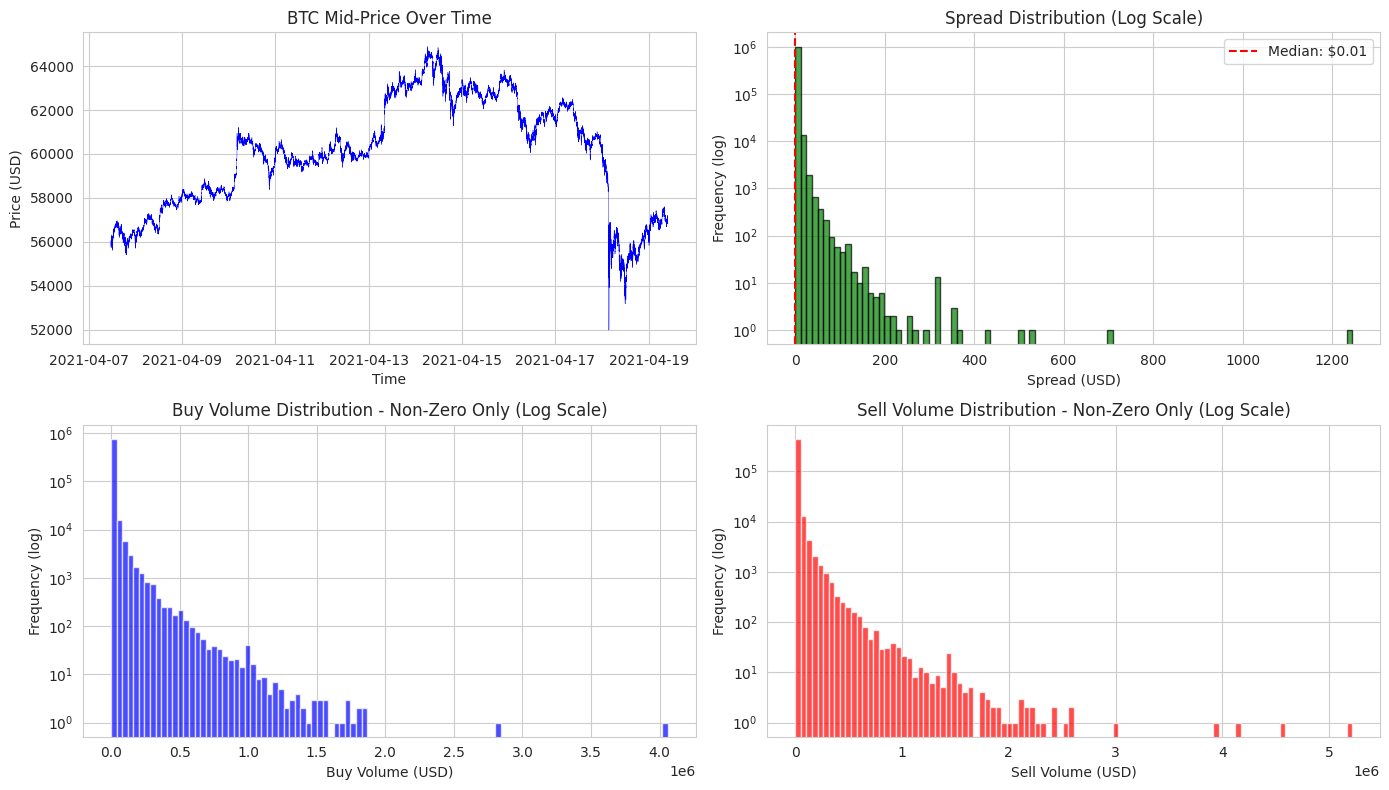


Seconds with zero buy volume: 23.5%
Seconds with zero sell volume: 54.9%


In [18]:
# ============================================================
# PRICE & SPREAD VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Midpoint price over time
axes[0, 0].plot(df['system_time'], df['midpoint'], linewidth=0.3, color='blue')
axes[0, 0].set_title('BTC Mid-Price Over Time', fontsize=12)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Price (USD)')

# 2. Spread distribution (log scale for better view of skewed data)
axes[0, 1].hist(df['spread'], bins=100, edgecolor='black', alpha=0.7, color='green', log=True)
axes[0, 1].set_title('Spread Distribution (Log Scale)', fontsize=12)
axes[0, 1].set_xlabel('Spread (USD)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].axvline(df['spread'].median(), color='red', linestyle='--', label=f"Median: ${df['spread'].median():.2f}")
axes[0, 1].legend()

# 3. Buy volume distribution (log scale)
axes[1, 0].hist(df[df['buys'] > 0]['buys'], bins=100, alpha=0.7, color='blue', log=True)
axes[1, 0].set_title('Buy Volume Distribution - Non-Zero Only (Log Scale)', fontsize=12)
axes[1, 0].set_xlabel('Buy Volume (USD)')
axes[1, 0].set_ylabel('Frequency (log)')

# 4. Sell volume distribution (log scale)
axes[1, 1].hist(df[df['sells'] > 0]['sells'], bins=100, alpha=0.7, color='red', log=True)
axes[1, 1].set_title('Sell Volume Distribution - Non-Zero Only (Log Scale)', fontsize=12)
axes[1, 1].set_xlabel('Sell Volume (USD)')
axes[1, 1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

# Print % of zero-volume seconds
pct_zero_buys = (df['buys'] == 0).mean() * 100
pct_zero_sells = (df['sells'] == 0).mean() * 100
print(f"\nSeconds with zero buy volume: {pct_zero_buys:.1f}%")
print(f"Seconds with zero sell volume: {pct_zero_sells:.1f}%")

### Price & Volume Distributions

The mid-price chart shows BTC rallying from \$56K to \$65K (April 7-14), then crashing to $52K by April 18. Having both an uptrend and correction in the data is useful — we can later check if LOB dynamics differ between regimes.

The spread is almost always at the minimum tick (\$0.01) — over 1 million observations there. Outliers at $600+ are rare (single occurrences) and likely correspond to the crash period when liquidity briefly vanished.

Buy and sell volumes both follow power-law distributions: most seconds are small, but there's a fat tail of whale trades. Sells have a longer tail ($5M+ max) and are more sparse — 55% of seconds have zero sell market orders vs 24% for buys. This asymmetry suggests retail buys continuously while large sells come in bursts.

*Note: Log scale is used for spread and volume histograms because the distributions are extremely right-skewed. On a linear scale, the dominant bar (e.g., $0.01 spread with 1M+ occurrences) would dwarf everything else, making the tail invisible.*

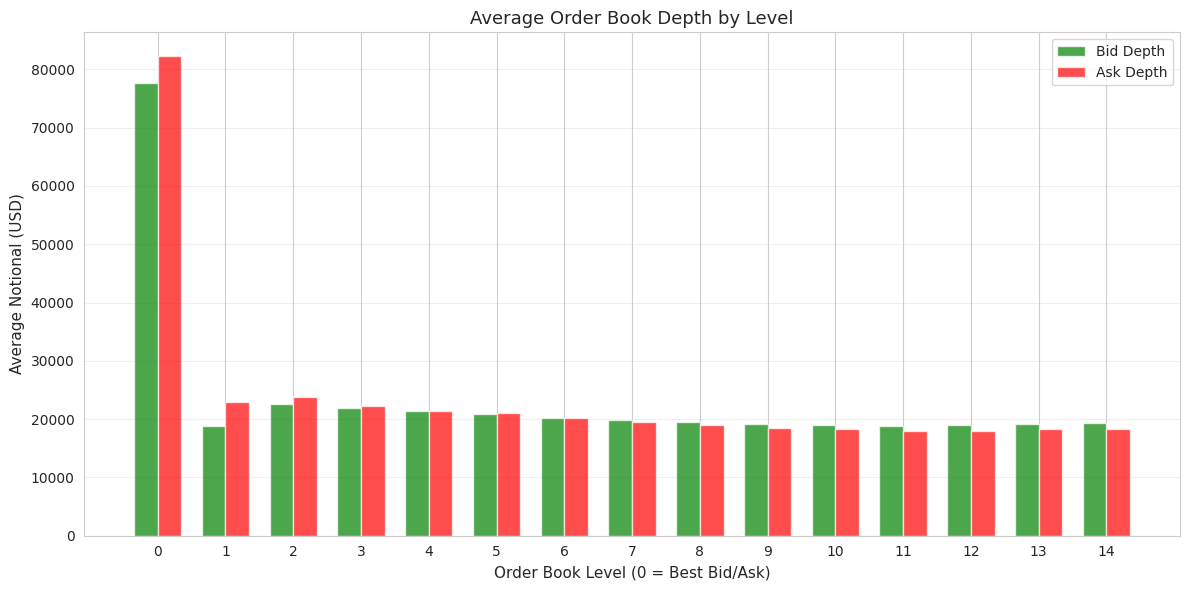

DEPTH SUMMARY (Average USD at each level)
Level         Bid Depth      Ask Depth      Imbalance
------------------------------------------------------------
0                77,728         82,245          -2.8%
1                18,755         23,011         -10.2%
2                22,599         23,730          -2.4%
3                21,919         22,275          -0.8%
4                21,373         21,473          -0.2%


In [19]:

# ============================================================
# ORDER BOOK DEPTH ANALYSIS
# ============================================================
# OBJECTIVE: Understand how liquidity is distributed across the 15
# price levels in the order book. We want to see:
# 1. Where do traders place most of their resting orders?
# 2. Is liquidity concentrated at the top (Level 0) or spread out?
# 3. Is there an imbalance between bid (buy) and ask (sell) depth?
# This helps us understand market structure and potential price pressure.
# ============================================================


# Calculate total depth at each level (sum of notional across all timestamps)
bid_notional_cols = [f'bids_notional_{i}' for i in range(15)]
ask_notional_cols = [f'asks_notional_{i}' for i in range(15)]

# Average notional at each level
avg_bid_depth = df[bid_notional_cols].mean()
avg_ask_depth = df[ask_notional_cols].mean()

# Plot depth profile
fig, ax = plt.subplots(figsize=(12, 6))

levels = range(15)
width = 0.35

bars1 = ax.bar([x - width/2 for x in levels], avg_bid_depth.values, width, label='Bid Depth', color='green', alpha=0.7)
bars2 = ax.bar([x + width/2 for x in levels], avg_ask_depth.values, width, label='Ask Depth', color='red', alpha=0.7)

ax.set_xlabel('Order Book Level (0 = Best Bid/Ask)', fontsize=11)
ax.set_ylabel('Average Notional (USD)', fontsize=11)
ax.set_title('Average Order Book Depth by Level', fontsize=13)
ax.set_xticks(levels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("="*60)
print("DEPTH SUMMARY (Average USD at each level)")
print("="*60)
print(f"{'Level':<8}{'Bid Depth':>15}{'Ask Depth':>15}{'Imbalance':>15}")
print("-"*60)
for i in range(5):  # Show first 5 levels
    bid = avg_bid_depth.iloc[i]
    ask = avg_ask_depth.iloc[i]
    imbalance = (bid - ask) / (bid + ask) * 100
    print(f"{i:<8}{bid:>15,.0f}{ask:>15,.0f}{imbalance:>14.1f}%")

### Order Book Depth Analysis

The depth profile shows a clear pattern: liquidity is heavily concentrated at Level 0 (best bid/ask), with roughly 77-82K USD on average. This drops sharply to ~20K USD at Level 1 and stays flat through Level 14.

This makes intuitive sense — traders compete to be at the best price because those orders execute first. Beyond the top of the book, there's no advantage to being at Level 5 vs Level 10, so liquidity distributes evenly.

The imbalance between bid and ask depth is consistently negative (-0.2% to -10.2%), meaning there are more resting sell orders than buy orders across the top 5 levels. This is consistent with the bearish price action in the second half of the dataset — during downtrends, sellers tend to stack limit orders while buyers pull back.

ORDER FLOW BREAKDOWN (Total USD over entire dataset)
               Bid Side (USD)  Ask Side (USD)     Total (USD)  % of Total
Limit Orders  190847183858.74 181370871152.72 372218055011.46       70.10
Market Orders   1354667408.97   1996916876.98   3351584285.95        0.60
Cancellations  82195515607.59  73493881038.03 155689396645.62       29.30


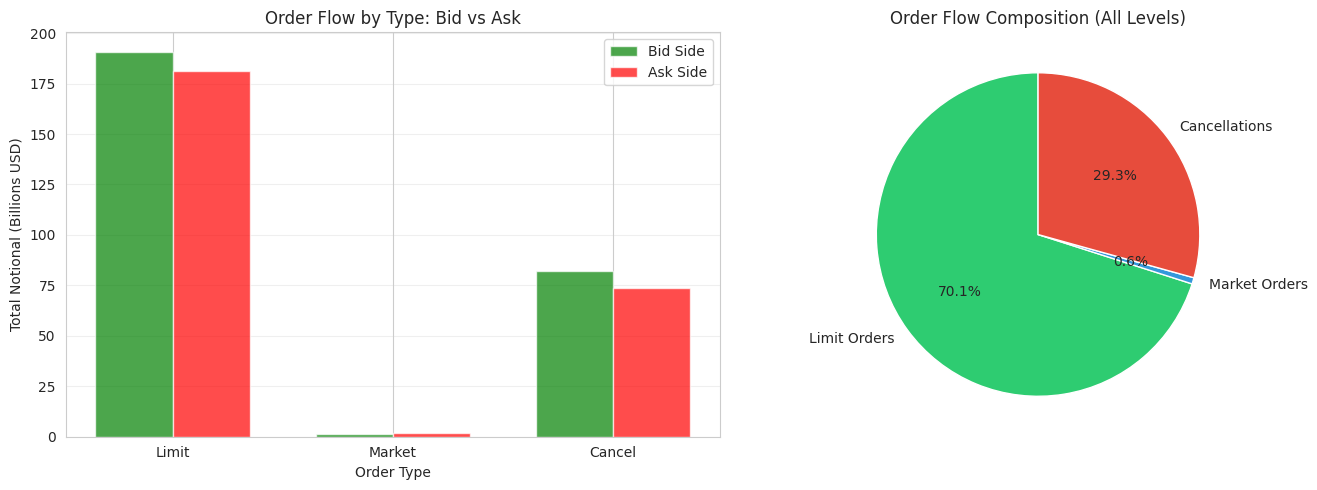


Cancel-to-Limit Ratio:
  Bid side: 43.1%
  Ask side: 40.5%


In [20]:
# ============================================================
# ORDER FLOW ANALYSIS: LIMIT vs MARKET vs CANCEL
# ============================================================
# OBJECTIVE: This dataset uniquely breaks down order activity into three
# components — limit orders (passive), market orders (aggressive), and
# cancellations. We want to understand:
# 1. What's the typical ratio of limit vs market vs cancel volume?
# 2. How does this differ between bid and ask sides?
# 3. Are cancellations significant? (High cancellations could indicate
#    spoofing or quote stuffing behavior)
# This decomposition is rare in public datasets and valuable for
# understanding market microstructure.
# ============================================================

# Sum total notional across all 15 levels for each order type
bid_limit = df[[f'bids_limit_notional_{i}' for i in range(15)]].sum().sum()
bid_market = df[[f'bids_market_notional_{i}' for i in range(15)]].sum().sum()
bid_cancel = df[[f'bids_cancel_notional_{i}' for i in range(15)]].sum().sum()

ask_limit = df[[f'asks_limit_notional_{i}' for i in range(15)]].sum().sum()
ask_market = df[[f'asks_market_notional_{i}' for i in range(15)]].sum().sum()
ask_cancel = df[[f'asks_cancel_notional_{i}' for i in range(15)]].sum().sum()

# Create summary dataframe
order_flow_summary = pd.DataFrame({
    'Bid Side (USD)': [bid_limit, bid_market, bid_cancel],
    'Ask Side (USD)': [ask_limit, ask_market, ask_cancel],
}, index=['Limit Orders', 'Market Orders', 'Cancellations'])

# Add totals and percentages
order_flow_summary['Total (USD)'] = order_flow_summary['Bid Side (USD)'] + order_flow_summary['Ask Side (USD)']
order_flow_summary['% of Total'] = (order_flow_summary['Total (USD)'] / order_flow_summary['Total (USD)'].sum() * 100).round(1)

print("="*70)
print("ORDER FLOW BREAKDOWN (Total USD over entire dataset)")
print("="*70)
print(order_flow_summary.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Stacked bar: Bid vs Ask by order type
order_types = ['Limit', 'Market', 'Cancel']
bid_values = [bid_limit/1e9, bid_market/1e9, bid_cancel/1e9]  # Convert to billions
ask_values = [ask_limit/1e9, ask_market/1e9, ask_cancel/1e9]

x = np.arange(len(order_types))
width = 0.35

axes[0].bar(x - width/2, bid_values, width, label='Bid Side', color='green', alpha=0.7)
axes[0].bar(x + width/2, ask_values, width, label='Ask Side', color='red', alpha=0.7)
axes[0].set_xlabel('Order Type')
axes[0].set_ylabel('Total Notional (Billions USD)')
axes[0].set_title('Order Flow by Type: Bid vs Ask')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order_types)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Pie chart: Overall composition
total_values = [bid_limit + ask_limit, bid_market + ask_market, bid_cancel + ask_cancel]
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[1].pie(total_values, labels=['Limit Orders', 'Market Orders', 'Cancellations'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Order Flow Composition (All Levels)')

plt.tight_layout()
plt.show()

# Cancel-to-Limit ratio (important microstructure metric)
cancel_to_limit_bid = bid_cancel / bid_limit * 100
cancel_to_limit_ask = ask_cancel / ask_limit * 100

print(f"\nCancel-to-Limit Ratio:")
print(f"  Bid side: {cancel_to_limit_bid:.1f}%")
print(f"  Ask side: {cancel_to_limit_ask:.1f}%")

### Order Flow Analysis: Limit vs Market vs Cancel

This dataset uniquely breaks down order activity into limit orders (passive), market orders (aggressive), and cancellations — a decomposition rarely available in public data.

**Composition:**
- Limit orders dominate at 70.1% of total notional (372B USD)
- Market orders are just 0.6% (3.4B USD) — expected since they execute instantly and don't accumulate
- Cancellations account for 29.3% (156B USD) — a significant portion

**Cancel-to-Limit Ratio:**
- Bid side: 43.1%
- Ask side: 40.5%

For every 100 USD of limit orders placed, roughly 40-43 USD gets cancelled before execution. This high cancellation rate reflects the nature of modern electronic markets — market makers and algorithms constantly update quotes as prices move. In crypto specifically, the absence of regulations against spoofing may contribute to higher cancellation rates.

**Bid vs Ask Asymmetry:**
Market orders on the ask side (2.0B USD) exceed bid side market orders (1.4B USD), indicating more aggressive selling pressure during this period. This aligns with the 20% price drop observed in the second half of the dataset.

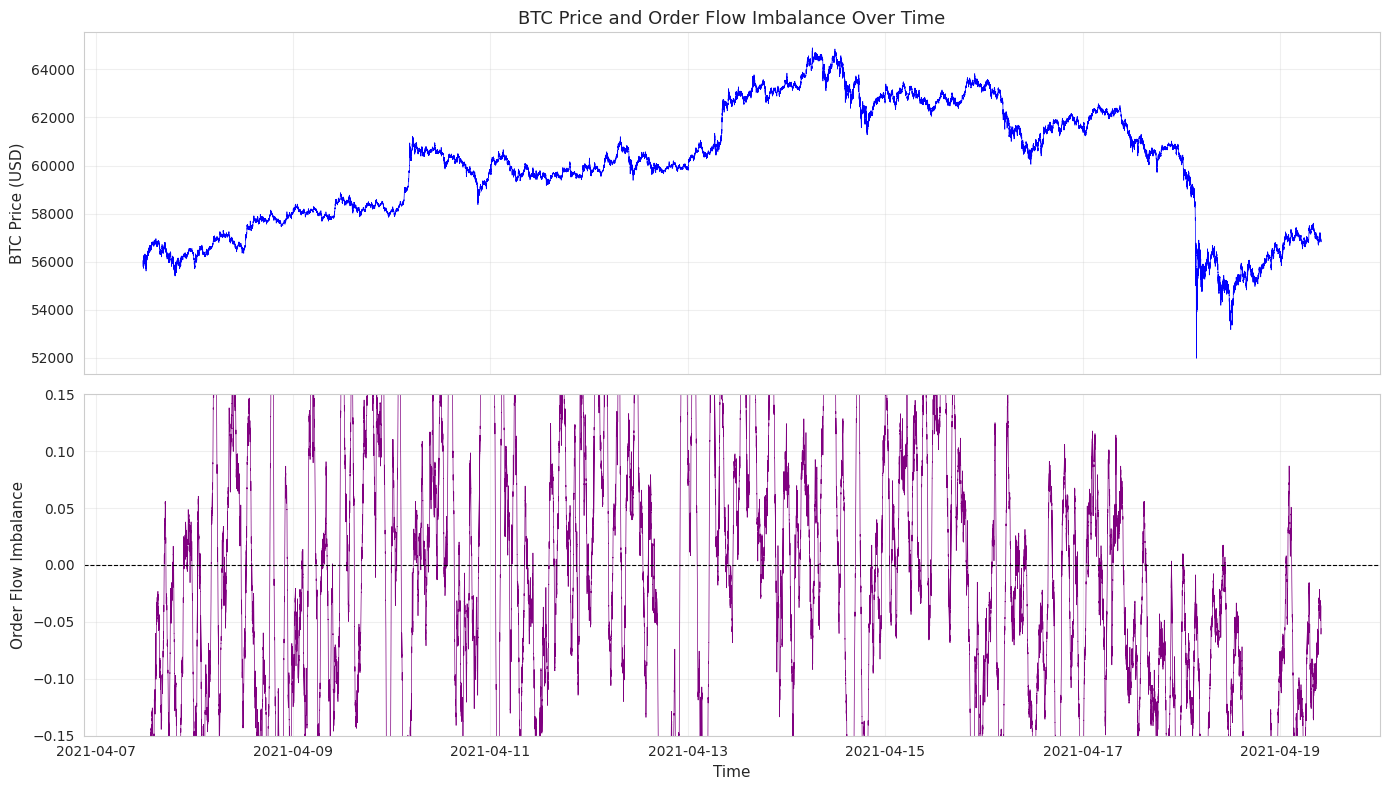

ORDER FLOW IMBALANCE SUMMARY
Mean OFI: -0.0138
Std OFI: 0.5089
Min OFI: -0.9960
Max OFI: 0.9988

Correlation (OFI vs 1-min future price change): 0.0923


In [21]:
# ============================================================
# ORDER FLOW IMBALANCE OVER TIME
# ============================================================
# OBJECTIVE: Order Flow Imbalance (OFI) measures the difference between
# buying and selling pressure. It's one of the most predictive features
# in market microstructure research. We want to:
# 1. Calculate OFI at each timestamp
# 2. Visualize how it evolves over time
# 3. See if OFI spikes correlate with price movements
# A positive OFI means more buying pressure; negative means selling pressure.
# ============================================================

# Calculate total bid and ask notional at each timestamp (sum across all 15 levels)
df['total_bid_notional'] = df[[f'bids_notional_{i}' for i in range(15)]].sum(axis=1)
df['total_ask_notional'] = df[[f'asks_notional_{i}' for i in range(15)]].sum(axis=1)

# Order Flow Imbalance (OFI): normalized difference between bid and ask depth
# Ranges from -1 (all asks) to +1 (all bids)
df['ofi'] = (df['total_bid_notional'] - df['total_ask_notional']) / (df['total_bid_notional'] + df['total_ask_notional'])

# Calculate rolling OFI (1-hour average) for smoother visualization
df['ofi_1h'] = df['ofi'].rolling(window=3600).mean()

# Create figure with 2 subplots sharing the x-axis
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Price over time
axes[0].plot(df['system_time'], df['midpoint'], linewidth=0.5, color='blue')
axes[0].set_ylabel('BTC Price (USD)', fontsize=11)
axes[0].set_title('BTC Price and Order Flow Imbalance Over Time', fontsize=13)
axes[0].grid(alpha=0.3)

# Plot 2: OFI over time (using 1-hour rolling average)
axes[1].plot(df['system_time'], df['ofi_1h'], linewidth=0.5, color='purple')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Order Flow Imbalance', fontsize=11)
axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_ylim(-0.15, 0.15)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics for OFI
print("="*60)
print("ORDER FLOW IMBALANCE SUMMARY")
print("="*60)
print(f"Mean OFI: {df['ofi'].mean():.4f}")
print(f"Std OFI: {df['ofi'].std():.4f}")
print(f"Min OFI: {df['ofi'].min():.4f}")
print(f"Max OFI: {df['ofi'].max():.4f}")

# Correlation between OFI and future price change
df['price_change_1min'] = df['midpoint'].shift(-60) - df['midpoint']
correlation = df['ofi'].corr(df['price_change_1min'])
print(f"\nCorrelation (OFI vs 1-min future price change): {correlation:.4f}")

### Order Flow Imbalance Over Time

Order Flow Imbalance (OFI) measures the relative difference between bid and ask depth, normalized to range from -1 (all asks) to +1 (all bids). It captures buying vs selling pressure in the order book.

**Summary Statistics:**
- Mean OFI: -0.014 (slightly more selling pressure on average)
- Standard deviation: 0.51 (highly volatile, swings frequently)
- Range: -0.996 to +0.999 (extreme one-sided books do occur)

**Predictive Value:**
The correlation between OFI and 1-minute future price change is 0.092. While this appears small, it's positive and statistically meaningful for financial data — it confirms that order book imbalance contains information about future price direction.

**Observations:**
- OFI oscillates rapidly around zero with no persistent trend
- During the April 18 crash, OFI became extremely volatile with frequent negative spikes — consistent with sellers overwhelming the book
- The signal is noisy at the 1-second level, suggesting feature engineering (rolling averages, combining with other features) will be necessary for prediction

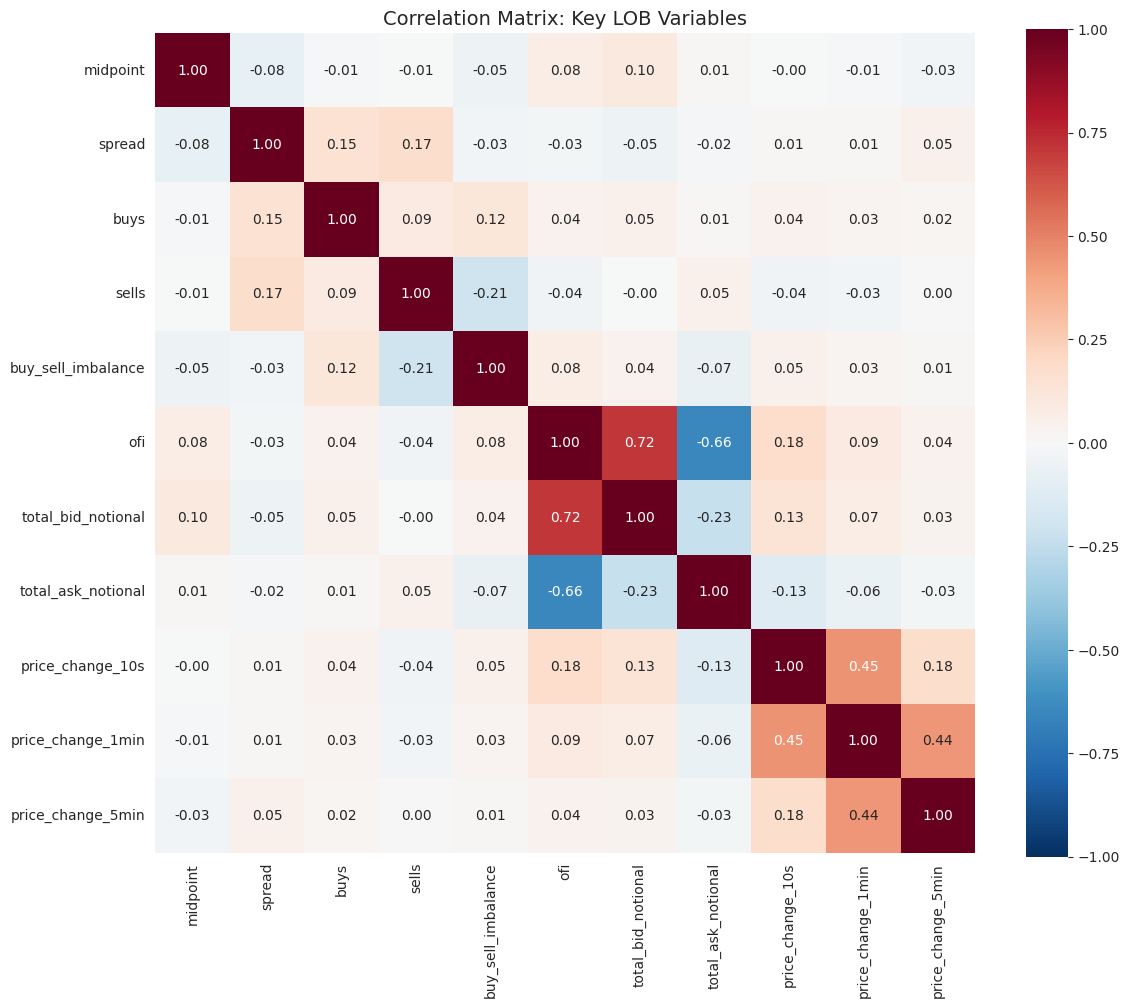

CORRELATIONS WITH FUTURE PRICE CHANGES

price_change_10s:
  spread              :   0.0078
  buys                :   0.0447
  sells               :  -0.0434
  buy_sell_imbalance  :   0.0490
  ofi                 :   0.1803

price_change_1min:
  spread              :   0.0098
  buys                :   0.0277
  sells               :  -0.0341
  buy_sell_imbalance  :   0.0261
  ofi                 :   0.0923

price_change_5min:
  spread              :   0.0497
  buys                :   0.0197
  sells               :   0.0034
  buy_sell_imbalance  :   0.0106
  ofi                 :   0.0413


In [22]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================
# OBJECTIVE: Examine relationships between key variables before feature
# engineering. We want to understand:
# 1. Which variables are correlated with each other?
# 2. Are there any multicollinearity issues (highly correlated features)?
# 3. Which raw features show preliminary relationship with price changes?
# This guides our feature engineering decisions.
# ============================================================

# Create price change variables at different horizons
df['price_change_10s'] = df['midpoint'].shift(-10) - df['midpoint']
df['price_change_1min'] = df['midpoint'].shift(-60) - df['midpoint']
df['price_change_5min'] = df['midpoint'].shift(-300) - df['midpoint']

# Calculate buy-sell imbalance (uses market orders, not depth)
df['buy_sell_imbalance'] = (df['buys'] - df['sells']) / (df['buys'] + df['sells'] + 1)

# Select key columns for correlation analysis
correlation_cols = [
    'midpoint',
    'spread',
    'buys',
    'sells',
    'buy_sell_imbalance',
    'ofi',
    'total_bid_notional',
    'total_ask_notional',
    'price_change_10s',
    'price_change_1min',
    'price_change_5min'
]

# Calculate correlation matrix
corr_matrix = df[correlation_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True)
plt.title('Correlation Matrix: Key LOB Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Extract correlations with price changes specifically
print("="*60)
print("CORRELATIONS WITH FUTURE PRICE CHANGES")
print("="*60)

price_change_cols = ['price_change_10s', 'price_change_1min', 'price_change_5min']
feature_cols = ['spread', 'buys', 'sells', 'buy_sell_imbalance', 'ofi']

for pc in price_change_cols:
    print(f"\n{pc}:")
    for feat in feature_cols:
        corr = df[feat].corr(df[pc])
        print(f"  {feat:<20}: {corr:>8.4f}")

### Correlation Analysis

The correlation matrix reveals key relationships between LOB variables and future price changes.

**Multicollinearity:**
OFI is highly correlated with total_bid_notional (+0.72) and total_ask_notional (-0.66) by construction. When using these features in a model, we should use OFI rather than raw depth to avoid redundancy.

**Activity clustering:**
Buys and sells are positively correlated (0.09), and both correlate with spread (0.15-0.17). This reflects market dynamics — volatile periods see increased activity on both sides and wider spreads.

**Predictive power (correlations with future price change):**

| Feature | 10 sec | 1 min | 5 min |
|---------|--------|-------|-------|
| OFI | 0.180 | 0.092 | 0.041 |
| buy_sell_imbalance | 0.049 | 0.026 | 0.011 |
| buys | 0.045 | 0.028 | 0.020 |
| sells | -0.043 | -0.034 | 0.003 |

**Key findings:**
1. OFI is the strongest predictor — 0.18 at 10-second horizon is meaningful for financial data
2. All signals decay with time — predictive power drops as horizon increases
3. Both depth-based (OFI) and flow-based (buy_sell_imbalance) features carry information
4. Shorter prediction horizons will likely yield better model performance

In [25]:
# ============================================================
# FEATURE ENGINEERING: DEPTH IMBALANCE FEATURES
# ============================================================
# OBJECTIVE: Create imbalance features at different levels of the order book.
# Level 0 (best bid/ask) may behave differently than deeper levels.
# We create:
# 1. Imbalance at individual levels (0, 1, 2, ...)
# 2. Imbalance aggregated over top-N levels
# 3. Imbalance weighted by distance from midpoint
# ============================================================

# 1. Individual level imbalance (for levels 0-4)
for i in range(5):
    bid_col = f'bids_notional_{i}'
    ask_col = f'asks_notional_{i}'
    df[f'depth_imbalance_level_{i}'] = (df[bid_col] - df[ask_col]) / (df[bid_col] + df[ask_col] + 1)

# 2. Aggregated imbalance over top-N levels
for n in [3, 5, 10]:
    bid_cols = [f'bids_notional_{i}' for i in range(n)]
    ask_cols = [f'asks_notional_{i}' for i in range(n)]

    total_bid = df[bid_cols].sum(axis=1)
    total_ask = df[ask_cols].sum(axis=1)

    df[f'depth_imbalance_top{n}'] = (total_bid - total_ask) / (total_bid + total_ask + 1)

# 3. Weighted imbalance (closer levels weighted more heavily)
weights = np.array([1/(i+1) for i in range(15)])
weights = weights / weights.sum()

bid_notional_cols = [f'bids_notional_{i}' for i in range(15)]
ask_notional_cols = [f'asks_notional_{i}' for i in range(15)]

weighted_bid = (df[bid_notional_cols].values * weights).sum(axis=1)
weighted_ask = (df[ask_notional_cols].values * weights).sum(axis=1)

df['depth_imbalance_weighted'] = (weighted_bid - weighted_ask) / (weighted_bid + weighted_ask + 1)

# Verify new features
print("Depth imbalance features created:")
depth_features = [col for col in df.columns if 'depth_imbalance' in col]
for feat in depth_features:
    print(f"  {feat}: min={df[feat].min():.3f}, max={df[feat].max():.3f}, mean={df[feat].mean():.4f}")

Depth imbalance features created:
  depth_imbalance_level_0: min=-1.000, max=1.000, mean=-0.0758
  depth_imbalance_level_1: min=-1.000, max=1.000, mean=-0.0789
  depth_imbalance_level_2: min=-1.000, max=1.000, mean=-0.0296
  depth_imbalance_level_3: min=-1.000, max=1.000, mean=-0.0192
  depth_imbalance_level_4: min=-1.000, max=1.000, mean=-0.0070
  depth_imbalance_top3: min=-1.000, max=1.000, mean=-0.0696
  depth_imbalance_top5: min=-1.000, max=1.000, mean=-0.0541
  depth_imbalance_top10: min=-0.997, max=0.999, mean=-0.0296
  depth_imbalance_weighted: min=-0.998, max=0.999, mean=-0.0447


### Depth Imbalance Features

Created 9 depth imbalance features capturing buy/sell pressure at different levels of the order book:

| Feature Type | Count | Description |
|--------------|-------|-------------|
| Individual levels | 5 | Imbalance at levels 0-4 separately |
| Aggregated | 3 | Imbalance over top 3, 5, and 10 levels |
| Weighted | 1 | All 15 levels, weighted by proximity to midpoint |

**Observations:**
- All features have negative means, confirming persistent sell-side pressure during this period
- Imbalance is strongest at levels 0-1 (mean ≈ -0.08) and weakens at deeper levels (level 4 mean ≈ -0.01)
- Aggregating over more levels dilutes the signal — top3 shows stronger imbalance than top10
- Individual level features may be more predictive than aggregated ones

In [26]:
# ============================================================
# FEATURE ENGINEERING: ORDER FLOW FEATURES
# ============================================================
# OBJECTIVE: Create features from the limit/market/cancel breakdown.
# These capture trading activity and aggression:
# 1. Net limit order flow (limit adds minus cancels)
# 2. Market order imbalance (aggressive buying vs selling)
# 3. Cancel ratio (what fraction of limit orders get cancelled)
# 4. Relative volume features
# ============================================================

# 1. Net limit order flow at top of book (level 0)
# Positive = more limit orders being added than cancelled
df['net_limit_flow_bid_0'] = df['bids_limit_notional_0'] - df['bids_cancel_notional_0']
df['net_limit_flow_ask_0'] = df['asks_limit_notional_0'] - df['asks_cancel_notional_0']

# Net flow imbalance: are buyers or sellers adding more to the book?
df['net_limit_flow_imbalance'] = (df['net_limit_flow_bid_0'] - df['net_limit_flow_ask_0']) / \
                                  (df['net_limit_flow_bid_0'].abs() + df['net_limit_flow_ask_0'].abs() + 1)

# 2. Market order imbalance (we already have this as buy_sell_imbalance, but let's create variations)
# Signed market flow: positive = net buying pressure
df['signed_market_flow'] = df['buys'] - df['sells']

# 3. Cancel intensity: ratio of cancels to limit orders
total_limit = df[[f'bids_limit_notional_{i}' for i in range(5)]].sum(axis=1) + \
              df[[f'asks_limit_notional_{i}' for i in range(5)]].sum(axis=1)
total_cancel = df[[f'bids_cancel_notional_{i}' for i in range(5)]].sum(axis=1) + \
               df[[f'asks_cancel_notional_{i}' for i in range(5)]].sum(axis=1)

df['cancel_intensity'] = total_cancel / (total_limit + 1)

# 4. Relative trade size: how big is this second's volume vs recent average?
df['buys_relative'] = df['buys'] / (df['buys'].rolling(300).mean() + 1)
df['sells_relative'] = df['sells'] / (df['sells'].rolling(300).mean() + 1)

# 5. Trade arrival rate: combined volume as proxy for activity
df['total_trade_volume'] = df['buys'] + df['sells']
df['volume_relative'] = df['total_trade_volume'] / (df['total_trade_volume'].rolling(300).mean() + 1)

# Verify new features
print("Order flow features created:")
flow_features = ['net_limit_flow_bid_0', 'net_limit_flow_ask_0', 'net_limit_flow_imbalance',
                 'signed_market_flow', 'cancel_intensity', 'buys_relative', 'sells_relative',
                 'total_trade_volume', 'volume_relative']
for feat in flow_features:
    non_null = df[feat].notna().sum()
    print(f"  {feat}: mean={df[feat].mean():.2f}, std={df[feat].std():.2f}, non-null={non_null:,}")

Order flow features created:
  net_limit_flow_bid_0: mean=20155.36, std=84385.42, non-null=1,030,728
  net_limit_flow_ask_0: mean=20813.55, std=83539.93, non-null=1,030,728
  net_limit_flow_imbalance: mean=-0.02, std=0.90, non-null=1,030,728
  signed_market_flow: mean=781.16, std=46036.02, non-null=1,030,728
  cancel_intensity: mean=93.47, std=3508.29, non-null=1,030,728
  buys_relative: mean=1.05, std=5.10, non-null=1,030,429
  sells_relative: mean=1.07, std=5.93, non-null=1,030,429
  total_trade_volume: mean=11338.96, std=50377.17, non-null=1,030,728
  volume_relative: mean=1.04, std=4.28, non-null=1,030,429


### Order Flow Features

Created 9 features capturing trading activity and order dynamics:

| Feature | Description | Mean | Std |
|---------|-------------|------|-----|
| net_limit_flow_bid_0 | Limit orders minus cancels (bid, level 0) | 20,155 | 84,385 |
| net_limit_flow_ask_0 | Limit orders minus cancels (ask, level 0) | 20,814 | 83,540 |
| net_limit_flow_imbalance | Normalized difference between bid/ask net flow | -0.02 | 0.90 |
| signed_market_flow | Buys minus sells (aggressive order imbalance) | 781 | 46,036 |
| cancel_intensity | Ratio of cancels to new limit orders | 93.5 | 3,508 |
| buys_relative | Current buys vs 5-min rolling average | 1.05 | 5.10 |
| sells_relative | Current sells vs 5-min rolling average | 1.07 | 5.93 |
| volume_relative | Total volume vs 5-min rolling average | 1.04 | 4.28 |

**Observations:**
- Net limit flow is slightly higher on the ask side (mean -0.02 imbalance), consistent with sell-side pressure
- Signed market flow is positive (net buying) yet price declined — highlights that resting depth, not just aggressive flow, determines price
- Cancel intensity is very high (93x on average), reflecting the rapid quote updating typical of HFT markets
- Relative volume features will help identify unusual activity spikes (whale trades, news events)

In [27]:
# ============================================================
# FEATURE ENGINEERING: SPREAD AND VOLATILITY FEATURES
# ============================================================
# OBJECTIVE: Spread reflects market quality and uncertainty. Volatility
# features capture recent price movement. These help the model understand
# market conditions:
# 1. Spread-based features (raw, relative, changes)
# 2. Realized volatility at different windows
# 3. Price momentum features
# ============================================================

# 1. Spread features
# Relative spread: spread as percentage of price
df['spread_bps'] = (df['spread'] / df['midpoint']) * 10000  # Basis points

# Spread vs recent average (is spread unusually wide?)
df['spread_relative'] = df['spread'] / (df['spread'].rolling(300).mean() + 0.001)

# Spread change
df['spread_change'] = df['spread'].diff()

# 2. Realized volatility (standard deviation of returns over rolling window)
df['returns'] = df['midpoint'].pct_change()  # 1-second returns

df['volatility_1min'] = df['returns'].rolling(60).std() * np.sqrt(60)    # Annualize-ish (scale up)
df['volatility_5min'] = df['returns'].rolling(300).std() * np.sqrt(300)

# 3. Price momentum features
df['momentum_10s'] = df['midpoint'] - df['midpoint'].shift(10)   # Price change over last 10 sec
df['momentum_1min'] = df['midpoint'] - df['midpoint'].shift(60)  # Price change over last 1 min
df['momentum_5min'] = df['midpoint'] - df['midpoint'].shift(300) # Price change over last 5 min

# Return over different horizons (percentage)
df['return_10s'] = df['midpoint'].pct_change(10) * 100
df['return_1min'] = df['midpoint'].pct_change(60) * 100
df['return_5min'] = df['midpoint'].pct_change(300) * 100

# Verify new features
print("Spread and volatility features created:")
sv_features = ['spread_bps', 'spread_relative', 'spread_change', 'returns',
               'volatility_1min', 'volatility_5min', 'momentum_10s', 'momentum_1min',
               'momentum_5min', 'return_10s', 'return_1min', 'return_5min']
for feat in sv_features:
    non_null = df[feat].notna().sum()
    print(f"  {feat}: mean={df[feat].mean():.4f}, std={df[feat].std():.4f}, non-null={non_null:,}")

Spread and volatility features created:
  spread_bps: mean=0.2225, std=0.8305, non-null=1,030,728
  spread_relative: mean=1.1019, std=4.0116, non-null=1,030,429
  spread_change: mean=-0.0000, std=4.3247, non-null=1,030,727
  returns: mean=0.0000, std=0.0001, non-null=1,030,727
  volatility_1min: mean=0.0006, std=0.0005, non-null=1,030,668
  volatility_5min: mean=0.0014, std=0.0010, non-null=1,030,428
  momentum_10s: mean=0.0080, std=22.0408, non-null=1,030,718
  momentum_1min: mean=0.0534, std=61.3754, non-null=1,030,668
  momentum_5min: mean=0.2810, std=142.0769, non-null=1,030,428
  return_10s: mean=0.0000, std=0.0377, non-null=1,030,718
  return_1min: mean=0.0002, std=0.1056, non-null=1,030,668
  return_5min: mean=0.0008, std=0.2442, non-null=1,030,428


### Spread and Volatility Features

Created 12 features capturing market quality, volatility, and momentum:

| Feature | Description | Mean | Std |
|---------|-------------|------|-----|
| spread_bps | Spread in basis points | 0.22 | 0.83 |
| spread_relative | Spread vs 5-min average | 1.10 | 4.01 |
| spread_change | Second-to-second spread change | 0.00 | 4.32 |
| volatility_1min | 1-minute rolling volatility | 0.0006 | 0.0005 |
| volatility_5min | 5-minute rolling volatility | 0.0014 | 0.0010 |
| momentum_10s/1min/5min | Price change over window | — | — |
| return_10s/1min/5min | Percentage return over window | — | — |

**Observations:**
- Average spread is just 0.22 basis points (~$0.01 on $60K BTC) — extremely liquid market
- Spread can spike to 4x normal (spread_relative std = 4.0) during volatile periods
- Momentum features have very low signal-to-noise ratios (small means, large std) — typical of financial data
- Volatility features will help the model adapt to changing market conditions (high volatility = less predictable)

In [28]:
# ============================================================
# FEATURE ENGINEERING: ROLLING AND LAGGED FEATURES
# ============================================================
# OBJECTIVE: Markets have memory — recent values often predict near-future
# values. We create:
# 1. Rolling averages of key features (smoothed signals)
# 2. Lagged values (what was OFI 10 seconds ago?)
# 3. Rolling correlations (how are features moving together recently?)
# These capture temporal patterns and regime changes.
# ============================================================

# 1. Rolling averages of OFI (different windows)
df['ofi_ma_10s'] = df['ofi'].rolling(10).mean()
df['ofi_ma_1min'] = df['ofi'].rolling(60).mean()
df['ofi_ma_5min'] = df['ofi'].rolling(300).mean()

# 2. Lagged OFI values
df['ofi_lag_1s'] = df['ofi'].shift(1)
df['ofi_lag_5s'] = df['ofi'].shift(5)
df['ofi_lag_10s'] = df['ofi'].shift(10)

# 3. OFI change (is order flow imbalance increasing or decreasing?)
df['ofi_change_1s'] = df['ofi'].diff(1)
df['ofi_change_10s'] = df['ofi'].diff(10)

# 4. Rolling averages of depth imbalance at level 0
df['depth_imb_0_ma_10s'] = df['depth_imbalance_level_0'].rolling(10).mean()
df['depth_imb_0_ma_1min'] = df['depth_imbalance_level_0'].rolling(60).mean()

# 5. Volume momentum (is activity increasing?)
df['volume_ma_1min'] = df['total_trade_volume'].rolling(60).mean()
df['volume_ma_5min'] = df['total_trade_volume'].rolling(300).mean()
df['volume_trend'] = df['volume_ma_1min'] / (df['volume_ma_5min'] + 1)  # >1 means activity increasing

# 6. Spread trend (is liquidity improving or worsening?)
df['spread_ma_1min'] = df['spread'].rolling(60).mean()
df['spread_ma_5min'] = df['spread'].rolling(300).mean()
df['spread_trend'] = df['spread_ma_1min'] / (df['spread_ma_5min'] + 0.001)  # >1 means spread widening

# Verify new features
print("Rolling and lagged features created:")
rl_features = ['ofi_ma_10s', 'ofi_ma_1min', 'ofi_ma_5min', 'ofi_lag_1s', 'ofi_lag_5s',
               'ofi_lag_10s', 'ofi_change_1s', 'ofi_change_10s', 'depth_imb_0_ma_10s',
               'depth_imb_0_ma_1min', 'volume_ma_1min', 'volume_ma_5min', 'volume_trend',
               'spread_ma_1min', 'spread_ma_5min', 'spread_trend']
for feat in rl_features:
    non_null = df[feat].notna().sum()
    print(f"  {feat}: mean={df[feat].mean():.4f}, non-null={non_null:,}")

Rolling and lagged features created:
  ofi_ma_10s: mean=-0.0138, non-null=1,030,719
  ofi_ma_1min: mean=-0.0138, non-null=1,030,669
  ofi_ma_5min: mean=-0.0138, non-null=1,030,429
  ofi_lag_1s: mean=-0.0138, non-null=1,030,727
  ofi_lag_5s: mean=-0.0138, non-null=1,030,723
  ofi_lag_10s: mean=-0.0138, non-null=1,030,718
  ofi_change_1s: mean=-0.0000, non-null=1,030,727
  ofi_change_10s: mean=0.0000, non-null=1,030,718
  depth_imb_0_ma_10s: mean=-0.0758, non-null=1,030,719
  depth_imb_0_ma_1min: mean=-0.0758, non-null=1,030,669
  volume_ma_1min: mean=11336.5846, non-null=1,030,669
  volume_ma_5min: mean=11326.2972, non-null=1,030,429
  volume_trend: mean=1.0078, non-null=1,030,429
  spread_ma_1min: mean=1.3139, non-null=1,030,669
  spread_ma_5min: mean=1.3133, non-null=1,030,429
  spread_trend: mean=1.0182, non-null=1,030,429


### Rolling and Lagged Features

Created 16 features capturing temporal patterns:

| Feature Group | Count | Description |
|---------------|-------|-------------|
| OFI rolling averages | 3 | Smoothed OFI over 10s, 1min, 5min windows |
| OFI lagged values | 3 | OFI from 1, 5, 10 seconds ago |
| OFI changes | 2 | First difference over 1s and 10s |
| Depth imbalance MAs | 2 | Smoothed level-0 imbalance |
| Volume MAs & trend | 3 | Activity level and trend |
| Spread MAs & trend | 3 | Liquidity level and trend |

**Observations:**
- Rolling averages preserve the mean while reducing noise — all OFI variants have mean = -0.014
- volume_trend ≈ 1.008 indicates stable activity levels overall
- spread_trend ≈ 1.018 suggests slight spread widening over time, consistent with the stress period in the data
- Lagged features enable the model to capture momentum effects (current price reacting to past order flow)

In [29]:
# ============================================================
# FEATURE ENGINEERING: TARGET VARIABLE
# ============================================================
# OBJECTIVE: Create the variable we want to predict. For classification,
# we'll predict price direction (up/down/flat) rather than exact price.
# We create targets at multiple horizons to test which is most predictable.
# Threshold for "flat" = price change < 0.01% (noise threshold)
# ============================================================

# Define threshold for "flat" classification (in percentage terms)
flat_threshold = 0.01  # 0.01% = 1 basis point

# Create directional targets at different horizons
for horizon, name in [(10, '10s'), (60, '1min'), (300, '5min')]:
    # Calculate future return
    future_return = (df['midpoint'].shift(-horizon) - df['midpoint']) / df['midpoint'] * 100

    # Classify into -1 (down), 0 (flat), +1 (up)
    conditions = [
        future_return < -flat_threshold,  # Down
        future_return > flat_threshold,   # Up
    ]
    choices = [-1, 1]

    df[f'target_{name}'] = np.select(conditions, choices, default=0)  # Default = flat

    # Also keep the continuous target for potential regression
    df[f'future_return_{name}'] = future_return

# Check target distribution
print("="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)

for name in ['10s', '1min', '5min']:
    target_col = f'target_{name}'
    valid = df[target_col].notna()

    down_pct = (df.loc[valid, target_col] == -1).mean() * 100
    flat_pct = (df.loc[valid, target_col] == 0).mean() * 100
    up_pct = (df.loc[valid, target_col] == 1).mean() * 100

    print(f"\n{name} horizon:")
    print(f"  Down (-1): {down_pct:.1f}%")
    print(f"  Flat (0):  {flat_pct:.1f}%")
    print(f"  Up (+1):   {up_pct:.1f}%")

TARGET VARIABLE DISTRIBUTION

10s horizon:
  Down (-1): 25.8%
  Flat (0):  48.0%
  Up (+1):   26.2%

1min horizon:
  Down (-1): 42.0%
  Flat (0):  14.9%
  Up (+1):   43.1%

5min horizon:
  Down (-1): 47.3%
  Flat (0):  5.5%
  Up (+1):   47.2%


### Target Variable

Created classification targets for three prediction horizons:

| Horizon | Down | Flat | Up | Notes |
|---------|------|------|-----|-------|
| 10 sec | 25.8% | 48.0% | 26.2% | High "flat" — price rarely moves in 10s |
| 1 min | 42.0% | 14.9% | 43.1% | Best balance — primary target for modeling |
| 5 min | 47.3% | 5.5% | 47.2% | Almost no "flat" — always moves over 5 min |

**Classification threshold:** ±0.01% (1 basis point). Movements smaller than this are classified as "flat."

**Recommendation:** Use the **1-minute horizon** as the primary target for modeling:
- Balanced classes (~42% down, 43% up)
- OFI correlation was strongest at shorter horizons (0.18 at 10s, 0.09 at 1min)
- Enough price movement to have meaningful predictions
- The 10s target has too many "flat" observations; the 5min target may be too noisy

In [30]:
# ============================================================
# FEATURE ENGINEERING: SUMMARY AND CLEANUP
# ============================================================
# OBJECTIVE: Review all features created, drop rows with NaN values,
# and prepare a clean dataset for modeling.
# ============================================================

# List all engineered features (excluding raw LOB columns)
raw_cols = ['Unnamed: 0', 'system_time', 'midpoint', 'spread', 'buys', 'sells']
raw_cols += [f'bids_distance_{i}' for i in range(15)]
raw_cols += [f'asks_distance_{i}' for i in range(15)]
raw_cols += [f'bids_notional_{i}' for i in range(15)]
raw_cols += [f'asks_notional_{i}' for i in range(15)]
raw_cols += [f'bids_cancel_notional_{i}' for i in range(15)]
raw_cols += [f'asks_cancel_notional_{i}' for i in range(15)]
raw_cols += [f'bids_limit_notional_{i}' for i in range(15)]
raw_cols += [f'asks_limit_notional_{i}' for i in range(15)]
raw_cols += [f'bids_market_notional_{i}' for i in range(15)]
raw_cols += [f'asks_market_notional_{i}' for i in range(15)]

engineered_features = [col for col in df.columns if col not in raw_cols]

print("="*60)
print(f"FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"Total columns in dataframe: {len(df.columns)}")
print(f"Raw LOB columns: {len(raw_cols)}")
print(f"Engineered features: {len(engineered_features)}")

print(f"\nEngineered features by category:")
categories = {
    'Depth Imbalance': [f for f in engineered_features if 'depth_imbalance' in f or 'depth_imb' in f],
    'Order Flow': [f for f in engineered_features if any(x in f for x in ['limit_flow', 'market_flow', 'cancel_intensity', 'buy_sell', 'signed_market', 'relative', 'trade_volume', 'volume_ma', 'volume_trend'])],
    'Spread & Volatility': [f for f in engineered_features if any(x in f for x in ['spread', 'volatility', 'returns', 'momentum', 'return_'])],
    'OFI Features': [f for f in engineered_features if 'ofi' in f],
    'Target Variables': [f for f in engineered_features if 'target' in f or 'future_return' in f or 'price_change' in f],
    'Other': [f for f in engineered_features if f in ['total_bid_notional', 'total_ask_notional']]
}

for cat, feats in categories.items():
    print(f"\n  {cat}: {len(feats)}")
    for f in feats[:5]:  # Show first 5
        print(f"    - {f}")
    if len(feats) > 5:
        print(f"    ... and {len(feats) - 5} more")

# Count NaN rows
nan_counts = df[engineered_features].isna().sum(axis=1)
rows_with_nan = (nan_counts > 0).sum()

print(f"\n" + "="*60)
print(f"DATA QUALITY")
print("="*60)
print(f"Rows with at least one NaN: {rows_with_nan:,} ({rows_with_nan/len(df)*100:.1f}%)")
print(f"Clean rows available: {len(df) - rows_with_nan:,}")

FEATURE ENGINEERING SUMMARY
Total columns in dataframe: 216
Raw LOB columns: 156
Engineered features: 60

Engineered features by category:

  Depth Imbalance: 11
    - depth_imbalance_level_0
    - depth_imbalance_level_1
    - depth_imbalance_level_2
    - depth_imbalance_level_3
    - depth_imbalance_level_4
    ... and 6 more

  Order Flow: 14
    - buy_sell_imbalance
    - net_limit_flow_bid_0
    - net_limit_flow_ask_0
    - net_limit_flow_imbalance
    - signed_market_flow
    ... and 9 more

  Spread & Volatility: 18
    - spread_bps
    - spread_relative
    - spread_change
    - returns
    - volatility_1min
    ... and 13 more

  OFI Features: 10
    - ofi
    - ofi_1h
    - ofi_ma_10s
    - ofi_ma_1min
    - ofi_ma_5min
    ... and 5 more

  Target Variables: 9
    - price_change_1min
    - price_change_10s
    - price_change_5min
    - target_10s
    - future_return_10s
    ... and 4 more

  Other: 2
    - total_bid_notional
    - total_ask_notional

DATA QUALITY
Rows with 

### Feature Engineering Summary

Created **60 engineered features** from the raw LOB data:

| Category | Count | Examples |
|----------|-------|----------|
| Depth Imbalance | 11 | Level-specific, aggregated, weighted imbalance |
| Order Flow | 14 | Limit/cancel flows, market order imbalance, volume trends |
| Spread & Volatility | 18 | Spread in bps, volatility, momentum, returns |
| OFI Features | 10 | Raw OFI, rolling averages, lags, changes |
| Target Variables | 9 | Direction and return at 10s, 1min, 5min horizons |

**Data quality:** Only 0.4% of rows have missing values (from rolling/shift operations). After cleanup, 1,026,829 rows are available for modeling.

**Next steps:**
1. Drop rows with NaN values
2. Select features for modeling (exclude targets and redundant features)
3. Save processed dataset for the modeling notebook

In [ ]:
# ============================================================
# SAVE PROCESSED DATASET
# ============================================================
# OBJECTIVE: Save the feature-engineered dataset so it can be loaded
# in notebook 02 for modeling. We drop NaN rows and save to Google Drive.
# ============================================================

# Drop rows with NaN values
df_clean = df.dropna()
print(f"Rows after dropping NaN: {len(df_clean):,}")

# Save to Google Drive
output_path = '/content/drive/MyDrive/BTC_features.csv'
df_clean.to_csv(output_path, index=False)
print(f"\n✓ Saved processed dataset to: {output_path}")
print(f"  File size: {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB (in memory)")

# Quick verification
df_verify = pd.read_csv(output_path, nrows=5)
print(f"  Columns: {len(df_verify.columns)}")
print(f"  Sample row count verified: {len(pd.read_csv(output_path)):,}")

Rows after dropping NaN: 1,026,829

✓ Saved processed dataset to: /content/drive/MyDrive/BTC_features.csv
  File size: 1782.6 MB (in memory)
  Columns: 216


---
## Notebook 01 Complete

**Summary:**
- Loaded 12 days of BTC limit order book data (1,030,728 rows × 156 columns)
- Performed EDA: price trends, spread analysis, order book depth, order flow breakdown
- Engineered 60 features across 5 categories
- Created target variables for 10s, 1min, and 5min price direction prediction
- Saved cleaned dataset (1,026,829 rows × 216 columns) for modeling

**Key findings from EDA:**
- Persistent sell-side pressure (negative depth imbalance throughout)
- OFI correlates with future price change (0.18 at 10s, 0.09 at 1min)
- 43% cancel-to-limit ratio indicates active quote management
- 1-minute horizon has best class balance for prediction

**Next:** Notebook 02 — Predictive Modeling